Shape: (891, 12)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Summary


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Duplicate Rows: 0
After Removal: 0


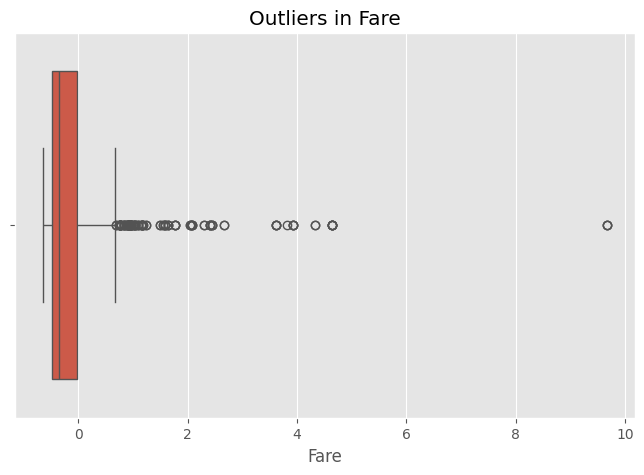

(775, 11)


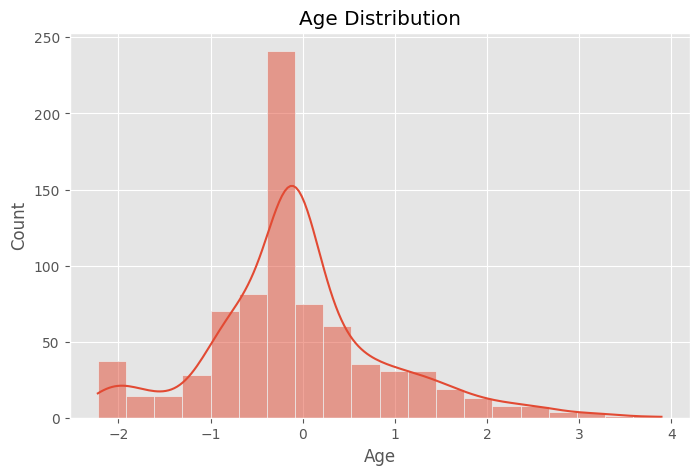

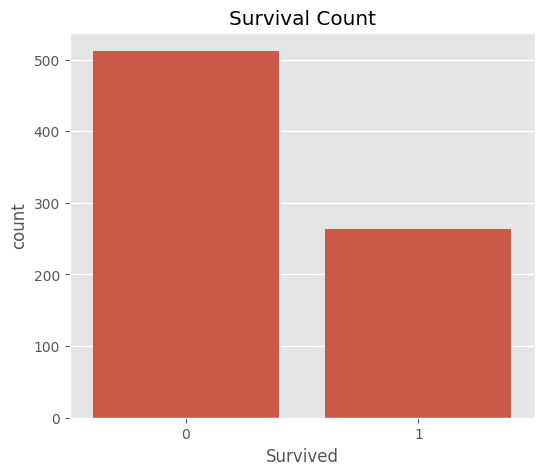

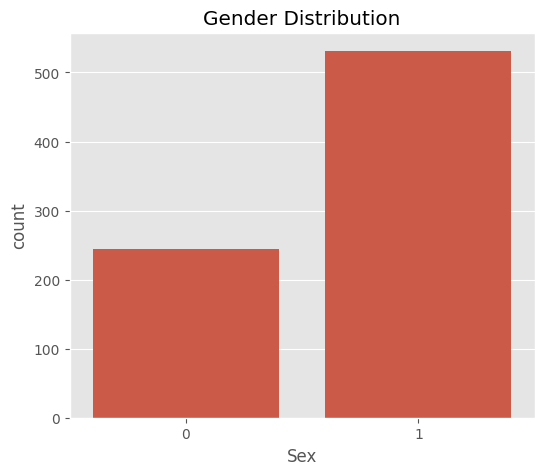

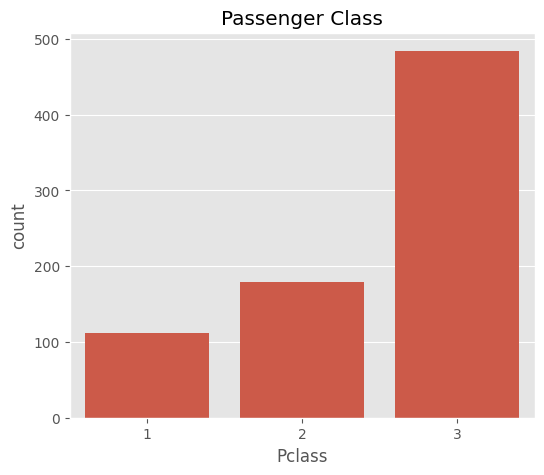

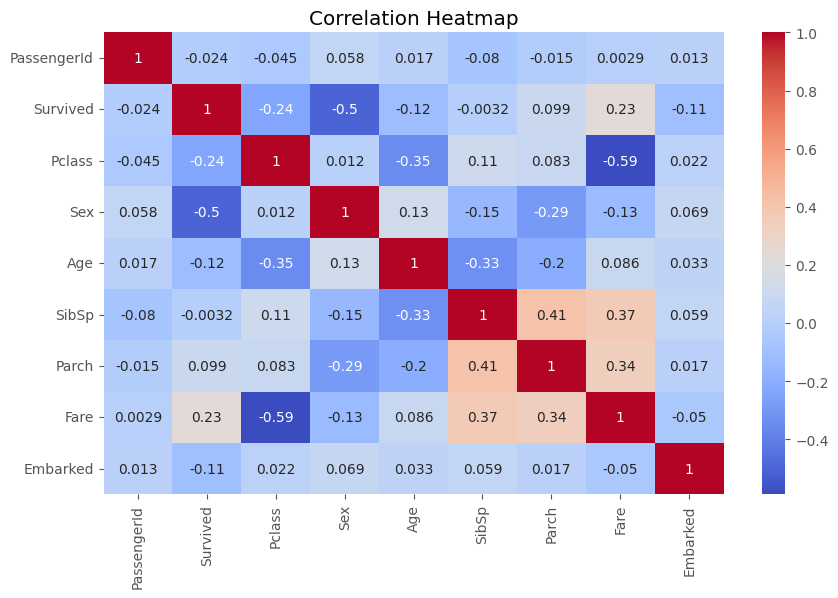

Dataset Saved Successfully


In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

#Load Dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")
df.head()

#Dataset Information
print("Shape:", df.shape)

print("\nInformation")
df.info()

print("\nSummary")
display(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

#Handle Missing Values
# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it has many missing values
df.drop(columns=["Cabin"], inplace=True)

print(df.isnull().sum())

#Remove Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("After Removal:", df.duplicated().sum())

#Encode Categorical Columns
encoder = LabelEncoder()
df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])
df.head()

#Standardization
scaler = StandardScaler()
columns = ["Age","Fare"]
df[columns] = scaler.fit_transform(df[columns])
df.head()

#Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Outliers in Fare")
plt.show()

#Remove Outliers
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df = df[(df["Fare"]>=lower) & (df["Fare"]<=upper)]
print(df.shape)

#Visualizations(Age Distribution)
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

#Survival Count
plt.figure(figsize=(6,5))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

#Gender Count
plt.figure(figsize=(6,5))
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

#Passenger Class
plt.figure(figsize=(6,5))
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class")
plt.show()

#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#Save Cleaned Dataset
df.to_csv("cleaned_titanic.csv", index=False)

print("Dataset Saved Successfully")